In [20]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [21]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [22]:
# fashion_mnist 데이터셋 내려받기
train_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download=True, transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download=True, train=False, transform=transforms.Compose([transforms.ToTensor()]))

In [23]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=100)

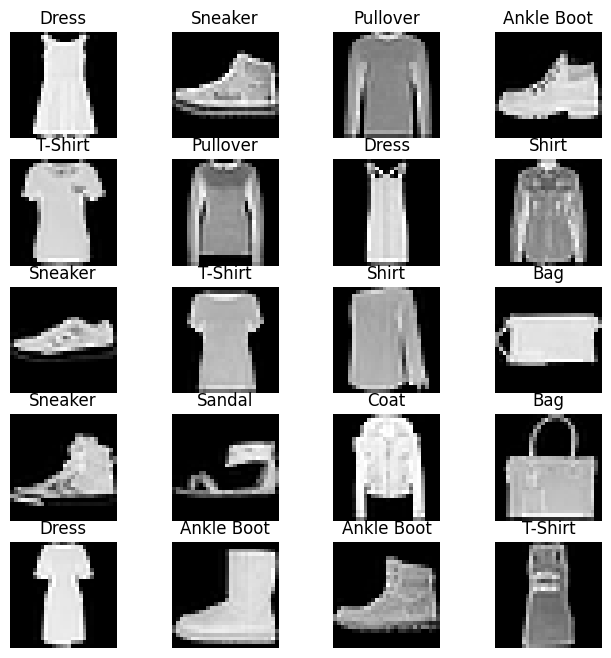

In [24]:
labels_map = {0 : 'T-Shirt', 1: 'Trouser', 2 : 'Pullover', 3: 'Dress', 4 : 'Coat', 5: 'Sandal', 6 : 'Shirt', 7 : 'Sneaker', 8 : 'Bag', 9 : 'Ankle Boot' }

fig = plt.figure (figsize=(8,8)); # 출력할 이미지의 가로세로 길이, inch
columns = 4;
rows = 5;
for i in range(1, columns*rows +1):
  img_xy = np.random.randint(len(train_dataset));
  img = train_dataset[img_xy][0][0,:,:]
  fig.add_subplot(rows, columns, i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img, cmap='gray')
plt.show()

In [25]:
class FashionDNN(nn. Module):
  def __init__(self):
    super(FashionDNN, self).__init__() # FashionDNN 클래스 상속 받음
    self.fc1 = nn.Linear(in_features=784, out_features=256)
    # in_features: 입력 크기, out_features: 출력 크기
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=256, out_features=128)
    self.fc3 = nn.Linear(in_features=128, out_features=10)

  def forward(self, input_data): # 실제 데이터 연산 진행됨, 순전파 학습 진행
    out = input_data.view(-1, 784) # 넘파이의 reshape와 같은 역할
    out = F.relu(self.fc1(out)) # 활성화 함수 정의
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

In [26]:
learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [27]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device) # 모델과 데이터는 동일한 장치에 있어야 함

    train = Variable(images.view(100, 1, 28, 28)) # Autograd 패키지 사용
    labels = Variable(labels)

    outputs = model(train) # 학습 데이터를 모델에 적용
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          labels_list.append(labels)
          test = Variable(images.view(100, 1, 28, 28))
          outputs = model(test)
          predictions = torch.max(outputs, 1) [1].to(device)
          predictions_list.append(predictions)
          correct += (predictions == labels).sum()
          total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5791972279548645, Accuracy: 83.25%
Iteration: 1000, Loss: 0.4822591543197632, Accuracy: 84.79000091552734%
Iteration: 1500, Loss: 0.3519760072231293, Accuracy: 84.4000015258789%
Iteration: 2000, Loss: 0.33230510354042053, Accuracy: 85.20999908447266%
Iteration: 2500, Loss: 0.25954797863960266, Accuracy: 86.01000213623047%
Iteration: 3000, Loss: 0.29675519466400146, Accuracy: 86.88999938964844%


In [28]:
class FashionCNN(nn. Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential(
      nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.layer2 = nn. Sequential(
      nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn. MaxPool2d(2)
    )
    self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
    self.drop = nn.Dropout2d(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features=120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1) # out.size(0) = 100을 의미
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

In [29]:
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [30]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device) # 모델과 데이터는 동일한 장치에 있어야 함

    train = Variable(images.view(100, 1, 28, 28)) # Autograd 패키지 사용
    labels = Variable(labels)

    outputs = model(train) # 학습 데이터를 모델에 적용
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          labels_list.append(labels)
          test = Variable(images.view(100, 1, 28, 28))
          outputs = model(test)
          predictions = torch.max(outputs, 1) [1].to(device)
          predictions_list.append(predictions)
          correct += (predictions == labels).sum()
          total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:1535: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:1535: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Iteration: 500, Loss: 0.48738548159599304, Accuracy: 87.18000030517578%
Iteration: 1000, Loss: 0.29624927043914795, Accuracy: 88.33000183105469%
Iteration: 1500, Loss: 0.2860810160636902, Accuracy: 87.0%
Iteration: 2000, Loss: 0.20732176303863525, Accuracy: 89.19999694824219%
Iteration: 2500, Loss: 0.12175137549638748, Accuracy: 89.55000305175781%
Iteration: 3000, Loss: 0.1846337914466858, Accuracy: 90.30999755859375%
